# Marketing Campaign Experimentation Analysis

## Project Objective

This project analyzes a marketing A/B test to understand whether users exposed to advertisements converted at a higher rate than users in the control group.

The goal is to measure conversion lift, check statistical significance, and translate the results into a business recommendation.

## 1. Download Dataset

The dataset is downloaded directly from Kaggle using `kagglehub`.

Dataset: Marketing A/B Testing Dataset  
Kaggle dataset path: `faviovaz/marketing-ab-testing`

In [1]:
# Install once:
# pip install kagglehub pandas

import kagglehub
import pandas as pd
from pathlib import Path
import shutil

# Kaggle dataset: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing
dataset_path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")

print("Dataset downloaded to:", dataset_path)

# Find CSV file
dataset_path = Path(dataset_path)
csv_files = list(dataset_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset folder.")

source_csv = csv_files[0]
target_csv = Path("marketing_AB.csv")

# Copy CSV into your current project folder with the expected name
shutil.copy(source_csv, target_csv)

print(f"Copied dataset to: {target_csv.resolve()}")

# Load dataset
df = pd.read_csv(target_csv)

print(df.head())
print(df.shape)

100%|██████████| 5.23M/5.23M [00:00<00:00, 62.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/faviovaz/marketing-ab-testing/versions/1
Copied dataset to: /content/marketing_AB.csv
   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  
(588101, 7)
Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')


## 2. Load Dataset

Now we load the downloaded CSV file into a pandas DataFrame and inspect the data.

At this stage, we want to understand:

- Number of rows and columns
- Column names
- Sample records
- Data types
- Basic summary statistics

In [3]:
# Load dataset
df = pd.read_csv("marketing_AB.csv")

# Show dataset shape
print("Dataset shape:", df.shape)

# Display first 5 rows
df.head()

Dataset shape: (588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [5]:
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [4]:
# Summary statistics for numeric and categorical columns
df.describe(include="all")

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
count,588101.000000,5.881010e+05,588101,588101,588101.000000,588101,588101.000000
unique,NaN,NaN,2,2,NaN,7,NaN
top,NaN,NaN,ad,False,NaN,Friday,NaN
freq,NaN,NaN,564577,573258,NaN,92608,NaN
mean,294050.000000,1.310692e+06,NaN,NaN,24.820876,NaN,14.469061
std,169770.279667,2.022260e+05,NaN,NaN,43.715181,NaN,4.834634
min,0.000000,9.000000e+05,NaN,NaN,1.000000,NaN,0.000000
25%,147025.000000,1.143190e+06,NaN,NaN,4.000000,NaN,11.000000
50%,294050.000000,1.313725e+06,NaN,NaN,13.000000,NaN,14.000000
75%,441075.000000,1.484088e+06,NaN,NaN,27.000000,NaN,18.000000


## 3. Clean Column Names

The original dataset has column names with spaces, such as `user id` and `test group`.

To make the code easier to write, we convert all column names to lowercase and replace spaces with underscores.

In [6]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Drop unnecessary index column if present
if "unnamed:_0" in df.columns:
    df = df.drop(columns=["unnamed:_0"])

# Check cleaned columns
df.columns

Index(['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')

## 4. Validate the Dataset

Before running the experiment analysis, we check:

- Missing values
- Duplicate users
- Test group values
- Conversion outcome values

In [7]:
# Required columns for this project
required_cols = [
    "user_id",
    "test_group",
    "converted",
    "total_ads",
    "most_ads_day",
    "most_ads_hour"
]

# Check if any required columns are missing
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("All required columns are present.")

All required columns are present.


In [8]:
# Check missing values
print("Missing values:")
print(df[required_cols].isna().sum())

Missing values:
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64


In [9]:
# Check duplicate users
print("Duplicate user IDs:", df["user_id"].duplicated().sum())

Duplicate user IDs: 0


In [10]:
# Check test group distribution
print("Test group counts:")
print(df["test_group"].value_counts())

Test group counts:
test_group
ad     564577
psa     23524
Name: count, dtype: int64


In [11]:
# Check conversion outcome values
print("Conversion values:")
print(df["converted"].value_counts())

Conversion values:
converted
False    573258
True      14843
Name: count, dtype: int64


In [12]:
# Remove duplicate users if any exist
df = df.drop_duplicates(subset=["user_id"])

# Convert conversion column to integer
df["converted"] = df["converted"].astype(int)

# Standardize test group values
df["test_group"] = df["test_group"].astype(str).str.lower().str.strip()

# Preview cleaned dataset
df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14


# Remove duplicate users if any exist
df = df.drop_duplicates(subset=["user_id"])

# Convert conversion column to integer
df["converted"] = df["converted"].astype(int)

# Standardize test group values
df["test_group"] = df["test_group"].astype(str).str.lower().str.strip()

# Preview cleaned dataset
df.head()

In [13]:
# Create experiment summary
summary = (
    df.groupby("test_group")
    .agg(
        users=("user_id", "count"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean"),
        avg_total_ads=("total_ads", "mean"),
        median_total_ads=("total_ads", "median")
    )
    .reset_index()
)

# Add percentage version of conversion rate
summary["conversion_rate_pct"] = summary["conversion_rate"] * 100

summary

,test_group,users,conversions,conversion_rate,avg_total_ads,median_total_ads,conversion_rate_pct
0,ad,564577,14423,0.025547,24.823365,13.0,2.554656
1,psa,23524,420,0.017854,24.761138,12.0,1.785411


## 6. Calculate Conversion Lift

Conversion lift tells us how much better the ad group performed compared to the control group.

We calculate:

- Treatment conversion rate
- Control conversion rate
- Absolute lift
- Relative lift

In [14]:
# Split treatment and control groups
treatment = df[df["test_group"] == "ad"]
control = df[df["test_group"] == "psa"]

# Group sizes
n_treat = len(treatment)
n_control = len(control)

# Number of conversions
conv_treat = treatment["converted"].sum()
conv_control = control["converted"].sum()

# Conversion rates
rate_treat = treatment["converted"].mean()
rate_control = control["converted"].mean()

# Lift calculations
absolute_lift = rate_treat - rate_control
relative_lift = absolute_lift / rate_control

print(f"Treatment users: {n_treat:,}")
print(f"Control users: {n_control:,}")

print(f"\nTreatment conversions: {conv_treat:,}")
print(f"Control conversions: {conv_control:,}")

print(f"\nTreatment conversion rate: {rate_treat:.4%}")
print(f"Control conversion rate: {rate_control:.4%}")

print(f"\nAbsolute lift: {absolute_lift:.4%}")
print(f"Relative lift: {relative_lift:.2%}")

Treatment users: 564,577
Control users: 23,524

Treatment conversions: 14,423
Control conversions: 420

Treatment conversion rate: 2.5547%
Control conversion rate: 1.7854%

Absolute lift: 0.7692%
Relative lift: 43.09%


## 7. Two-Proportion Z-Test

Now we test whether the conversion rate difference between the ad group and the control group is statistically significant.

### Hypotheses

**Null hypothesis:**  
There is no difference in conversion rate between users who saw ads and users in the control group.

**Alternative hypothesis:**  
There is a difference in conversion rate between users who saw ads and users in the control group.

We use a two-proportion z-test because the outcome is binary: converted or not converted.

In [17]:
# Two-proportion z-test
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
count = np.array([conv_treat, conv_control])
nobs = np.array([n_treat, n_control])

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Z-statistic: 7.3701
P-value: 0.000000


In [18]:
# Interpret test result

alpha = 0.05

if p_value < alpha:
    print("Result: Statistically significant difference in conversion rates.")
else:
    print("Result: No statistically significant difference in conversion rates.")

Result: Statistically significant difference in conversion rates.


## 9. Confidence Intervals for Conversion Rates

The z-test tells us whether the difference is statistically significant.

Confidence intervals help us understand the likely range of the true conversion rate for each group.

In [20]:
# Confidence intervals for conversion rates
from statsmodels.stats.proportion import proportion_confint

ci_treat = proportion_confint(
    count=conv_treat,
    nobs=n_treat,
    alpha=0.05,
    method="wilson"
)

ci_control = proportion_confint(
    count=conv_control,
    nobs=n_control,
    alpha=0.05,
    method="wilson"
)

print(f"Treatment conversion rate 95% CI: {ci_treat[0]:.4%} to {ci_treat[1]:.4%}")
print(f"Control conversion rate 95% CI: {ci_control[0]:.4%} to {ci_control[1]:.4%}")

Treatment conversion rate 95% CI: 2.5138% to 2.5961%
Control conversion rate 95% CI: 1.6239% to 1.9627%


## 10. Bootstrap Confidence Interval for Conversion Lift

Now we estimate the confidence interval for the conversion lift.

This helps answer:

> How much did the ad campaign likely improve conversion?

In [21]:
# Bootstrap confidence interval for absolute lift

np.random.seed(42)

bootstrap_lifts = []

for _ in range(5000):
    treatment_sample = treatment["converted"].sample(n=n_treat, replace=True)
    control_sample = control["converted"].sample(n=n_control, replace=True)

    lift = treatment_sample.mean() - control_sample.mean()
    bootstrap_lifts.append(lift)

bootstrap_lifts = np.array(bootstrap_lifts)

lift_ci_low, lift_ci_high = np.percentile(bootstrap_lifts, [2.5, 97.5])

print(f"Bootstrap 95% CI for absolute lift: {lift_ci_low:.4%} to {lift_ci_high:.4%}")

Bootstrap 95% CI for absolute lift: 0.5911% to 0.9412%


## 11. Logistic Regression

The z-test compares raw conversion rates between the ad group and the control group.

Now we use logistic regression to check whether being in the ad group is still associated with higher conversion after accounting for other factors, such as:

- Number of ads seen
- Day with the most ad exposure
- Hour with the most ad exposure

The outcome variable is `converted`, which is binary: 1 for converted and 0 for not converted.

In [22]:
# Create modeling dataset
model_df = df.copy()

# Create treatment indicator
# 1 = ad group, 0 = control/PSA group
model_df["is_ad_group"] = (model_df["test_group"] == "ad").astype(int)

# Preview modeling columns
model_df[["converted", "is_ad_group", "total_ads", "most_ads_day", "most_ads_hour"]].head()

,converted,is_ad_group,total_ads,most_ads_day,most_ads_hour
0,0,1,130,Monday,20
1,0,1,93,Tuesday,22
2,0,1,21,Tuesday,18
3,0,1,355,Tuesday,10
4,0,1,276,Friday,14


In [25]:
# Run logistic regression
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf

logit_model = smf.logit(
    formula="converted ~ is_ad_group + total_ads + C(most_ads_day) + C(most_ads_hour)",
    data=model_df
).fit(disp=False)

print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588069
Method:                           MLE   Df Model:                           31
Date:                Sun, 31 May 2026   Pseudo R-squ.:                 0.08198
Time:                        17:45:52   Log-Likelihood:                -63588.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -4.9463      0.117    -42.260      0.000      -5.176      -4.717
C(most_ads_day)[T.Monday]        0.4613      0.031     15.029      0.000     

## 12. Interpret Logistic Regression with Odds Ratios

Logistic regression coefficients are not very easy to explain directly.

So we convert them into odds ratios:

- Odds ratio greater than 1 means higher odds of conversion
- Odds ratio less than 1 means lower odds of conversion
- Odds ratio around 1 means little or no difference

In [26]:
# Convert coefficients to odds ratios
odds_ratios = np.exp(logit_model.params)

odds_ratio_table = (
    pd.DataFrame({
        "feature": odds_ratios.index,
        "odds_ratio": odds_ratios.values
    })
    .sort_values("odds_ratio", ascending=False)
)

odds_ratio_table

,feature,odds_ratio
22,C(most_ads_hour)[T.16],1.806882
27,C(most_ads_hour)[T.21],1.592334
26,C(most_ads_hour)[T.20],1.587710
1,C(most_ads_day)[T.Monday],1.586130
21,C(most_ads_hour)[T.15],1.569891
23,C(most_ads_hour)[T.17],1.552288
5,C(most_ads_day)[T.Tuesday],1.542029
20,C(most_ads_hour)[T.14],1.537013
28,C(most_ads_hour)[T.22],1.516433
30,is_ad_group,1.471308


In [27]:
# Focus on the ad group effect
ad_group_odds_ratio = odds_ratios["is_ad_group"]
ad_group_p_value = logit_model.pvalues["is_ad_group"]

print(f"Ad group odds ratio: {ad_group_odds_ratio:.4f}")
print(f"Ad group p-value: {ad_group_p_value:.6f}")

if ad_group_p_value < 0.05 and ad_group_odds_ratio > 1:
    print("After controlling for ad exposure, day, and hour, the ad group is still associated with higher conversion.")
elif ad_group_p_value < 0.05 and ad_group_odds_ratio < 1:
    print("After controlling for ad exposure, day, and hour, the ad group is associated with lower conversion.")
else:
    print("After controlling for ad exposure, day, and hour, the ad group effect is not statistically significant.")

Ad group odds ratio: 1.4713
Ad group p-value: 0.000000
After controlling for ad exposure, day, and hour, the ad group is still associated with higher conversion.


## 13. Segment Analysis

After checking the overall experiment result, we now look at where the campaign performed better or worse.

We analyze conversion lift by:

- Day with the most ad exposure
- Hour with the most ad exposure

This helps understand whether campaign performance changes across timing patterns.

In [28]:
# Conversion lift by day

day_summary = (
    df.groupby(["most_ads_day", "test_group"])
    .agg(
        users=("user_id", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

day_pivot = day_summary.pivot(
    index="most_ads_day",
    columns="test_group",
    values="conversion_rate"
).reset_index()

day_pivot["absolute_lift"] = day_pivot["ad"] - day_pivot["psa"]
day_pivot["relative_lift"] = day_pivot["absolute_lift"] / day_pivot["psa"]

day_pivot = day_pivot.sort_values("absolute_lift", ascending=False)

day_pivot

test_group,most_ads_day,ad,psa,absolute_lift,relative_lift
5,Tuesday,0.030440,0.014448,0.015992,1.106909
1,Monday,0.033241,0.022559,0.010683,0.473553
6,Wednesday,0.025356,0.015759,0.009597,0.608945
2,Saturday,0.021307,0.013996,0.007311,0.522354
0,Friday,0.022465,0.016303,0.006162,0.377971
3,Sunday,0.024620,0.020595,0.004025,0.195430
4,Thursday,0.021637,0.020230,0.001407,0.069532


In [29]:
# Conversion lift by hour

hour_summary = (
    df.groupby(["most_ads_hour", "test_group"])
    .agg(
        users=("user_id", "count"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

hour_pivot = hour_summary.pivot(
    index="most_ads_hour",
    columns="test_group",
    values="conversion_rate"
).reset_index()

hour_pivot["absolute_lift"] = hour_pivot["ad"] - hour_pivot["psa"]
hour_pivot["relative_lift"] = hour_pivot["absolute_lift"] / hour_pivot["psa"]

hour_pivot = hour_pivot.sort_values("absolute_lift", ascending=False)

hour_pivot.head(10)

test_group,most_ads_hour,ad,psa,absolute_lift,relative_lift
6,6,0.023174,0.000000,0.023174,inf
5,5,0.021563,0.000000,0.021563,inf
0,0,0.019213,0.000000,0.019213,inf
4,4,0.015850,0.000000,0.015850,inf
1,1,0.013434,0.000000,0.013434,inf
20,20,0.030274,0.017642,0.012632,0.716038
14,14,0.028575,0.016051,0.012524,0.780244
22,22,0.026455,0.016358,0.010097,0.617284
23,23,0.022970,0.012924,0.010046,0.777325
7,7,0.018482,0.008439,0.010044,1.190175


## 14. Segment Interpretation

The day and hour analysis helps identify when the ad campaign appears to perform best.

However, segment-level results should be interpreted carefully because smaller groups can be noisier than the overall experiment.

In [30]:
# Print best-performing day and hour based on absolute lift

best_day = day_pivot.iloc[0]
best_hour = hour_pivot.iloc[0]

print("Best-performing day:")
print(f"Day: {best_day['most_ads_day']}")
print(f"Ad conversion rate: {best_day['ad']:.4%}")
print(f"Control conversion rate: {best_day['psa']:.4%}")
print(f"Absolute lift: {best_day['absolute_lift']:.4%}")

print("\nBest-performing hour:")
print(f"Hour: {int(best_hour['most_ads_hour'])}")
print(f"Ad conversion rate: {best_hour['ad']:.4%}")
print(f"Control conversion rate: {best_hour['psa']:.4%}")
print(f"Absolute lift: {best_hour['absolute_lift']:.4%}")

Best-performing day:
Day: Tuesday
Ad conversion rate: 3.0440%
Control conversion rate: 1.4448%
Absolute lift: 1.5992%

Best-performing hour:
Hour: 6
Ad conversion rate: 2.3174%
Control conversion rate: 0.0000%
Absolute lift: 2.3174%


## 15. Visualize Experiment Results

Now we create simple charts to explain the experiment results clearly.

We will visualize:

- Conversion rate by group
- Total ads distribution
- Conversion lift by day
- Conversion lift by hour

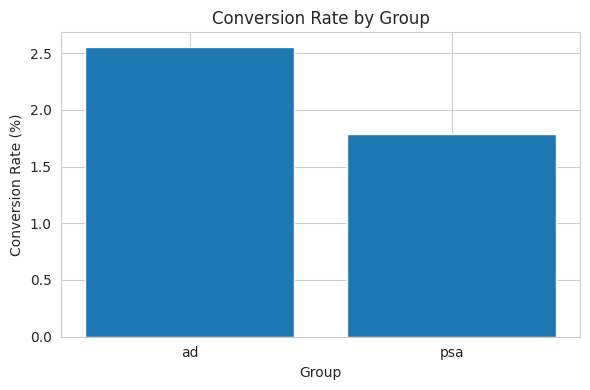

In [32]:
# Conversion rate by group
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
plt.bar(summary["test_group"], summary["conversion_rate_pct"])
plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()

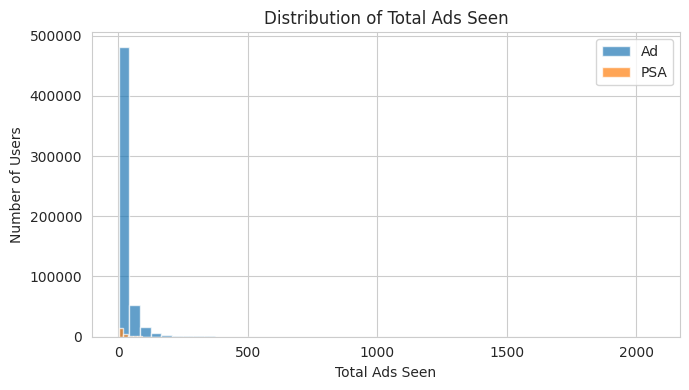

In [33]:
# Distribution of total ads seen by group

plt.figure(figsize=(7, 4))
plt.hist(
    df[df["test_group"] == "ad"]["total_ads"],
    bins=50,
    alpha=0.7,
    label="Ad"
)

plt.hist(
    df[df["test_group"] == "psa"]["total_ads"],
    bins=50,
    alpha=0.7,
    label="PSA"
)

plt.title("Distribution of Total Ads Seen")
plt.xlabel("Total Ads Seen")
plt.ylabel("Number of Users")
plt.legend()
plt.tight_layout()
plt.show()

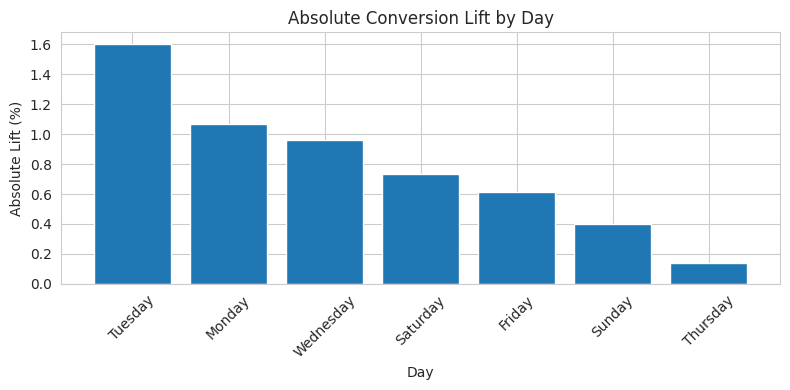

In [34]:
# Conversion lift by day

plt.figure(figsize=(8, 4))
plt.bar(day_pivot["most_ads_day"], day_pivot["absolute_lift"] * 100)
plt.title("Absolute Conversion Lift by Day")
plt.xlabel("Day")
plt.ylabel("Absolute Lift (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

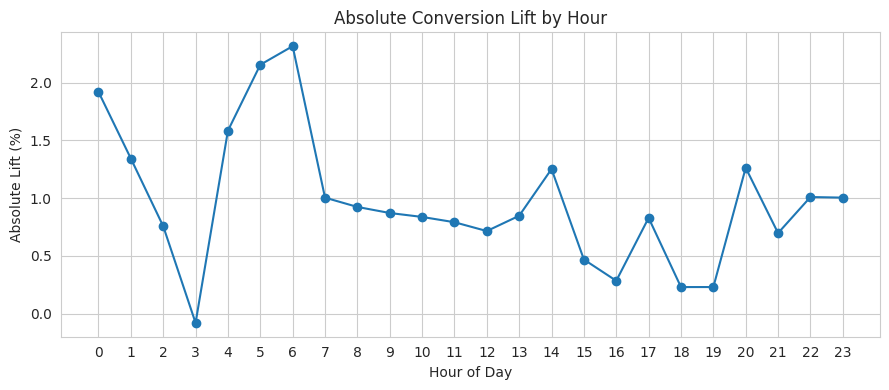

In [35]:
# Conversion lift by hour

hour_pivot_sorted = hour_pivot.sort_values("most_ads_hour")

plt.figure(figsize=(9, 4))
plt.plot(
    hour_pivot_sorted["most_ads_hour"],
    hour_pivot_sorted["absolute_lift"] * 100,
    marker="o"
)

plt.title("Absolute Conversion Lift by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Absolute Lift (%)")
plt.xticks(hour_pivot_sorted["most_ads_hour"])
plt.tight_layout()
plt.show()

## 17. Final Business Recommendation

The final recommendation uses the main experiment results:

- Conversion rate difference
- Absolute and relative lift
- Statistical significance
- Confidence interval for lift
- Logistic regression result

The goal is to turn the statistical analysis into a clear business decision.

Final Business Recommendation
--------------------------------------------------
The ad campaign improved conversion. The ad group converted at 2.55%, compared with 1.79% for the control group. This equals an absolute lift of 0.77% and a relative lift of 43.09%. The result is statistically significant, so the campaign can be scaled further. However, the team should continue monitoring cost per conversion and performance across days and hours.